In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/prompts.csv")

In [4]:
annotator_cols = [c for c in df.columns if c.startswith('annotator_')]
meta_cols = [c for c in df.columns if c not in annotator_cols]

def collect_annotations(row):
    present = row[annotator_cols].dropna()
    names = [c.replace('annotator_', '') for c in present.index]
    vals = present.tolist()
    return pd.Series({
        'annotator_1':      vals[0]  if len(vals) > 0 else pd.NA,
        'annotator_1_name': names[0] if len(vals) > 0 else pd.NA,
        'annotator_2':      vals[1]  if len(vals) > 1 else pd.NA,
        'annotator_2_name': names[1] if len(vals) > 1 else pd.NA,
    })

annotations = df.apply(collect_annotations, axis=1)
df_polished = pd.concat([df[meta_cols].reset_index(drop=True),
                         annotations.reset_index(drop=True)], axis=1)

In [11]:
import json
import pandas as pd

def parse_annotation(val):
    if pd.isna(val):
        return {'category': pd.NA, 'violation': pd.NA, 'confidence': pd.NA}
    d = val if isinstance(val, dict) else json.loads(val)
    cats = d.get('category')
    return {
        'category':  ', '.join(cats) if isinstance(cats, list) else cats,
        'violation': d.get('violation'),
        'confidence': d.get('confidence'),
    }

for col in ['annotator_1', 'annotator_2']:
    parsed = df_polished[col].apply(parse_annotation).apply(pd.Series)
    parsed.columns = [f'{col}_{c}' for c in parsed.columns]
    df_polished = pd.concat([df_polished, parsed], axis=1)

In [22]:
df_sum = df_polished[['question','domain','safe_or_unsafe','color_label','annotator_1_category','annotator_2_category','annotator_1_confidence','annotator_2_confidence','annotator_1_violation','annotator_2_violation']]

In [25]:
"""
Inter-annotator agreement + annotator-vs-prediction analysis for df_sum.

Color rule (color_label is treated as the "prediction"):
    red    -> confidence = confident, violation = yes
    yellow -> confidence = uncertain, violation = (unspecified)
    blue   -> confidence = confident, violation = no
"""

import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix

# ---------------------------------------------------------------------------
# 0. Clean
# ---------------------------------------------------------------------------
df = df_sum.dropna().copy()

text_cols = [
    'annotator_1_category', 'annotator_2_category',
    'annotator_1_confidence', 'annotator_2_confidence',
    'annotator_1_violation', 'annotator_2_violation',
    'color_label', 'domain',
]
for c in text_cols:
    df[c] = df[c].astype(str).str.strip().str.lower()

print(f"Rows after dropping NaNs: {len(df)}\n")


# ---------------------------------------------------------------------------
# Helper: percent agreement + Cohen's kappa
# ---------------------------------------------------------------------------
def agreement(a, b, name):
    pct = (a == b).mean()
    try:
        kappa = cohen_kappa_score(a, b)
    except Exception:
        kappa = np.nan
    print(f"  {name:12s} | % agreement: {pct:6.3f} | Cohen's kappa: {kappa:6.3f}")
    return {'metric': name, 'pct_agreement': pct, 'cohens_kappa': kappa}


# ---------------------------------------------------------------------------
# 1. INTER-ANNOTATOR AGREEMENT (annotator 1 vs annotator 2)
# ---------------------------------------------------------------------------
print("=== 1. Inter-annotator agreement (annotator_1 vs annotator_2) ===")
iaa = [
    agreement(df['annotator_1_violation'],   df['annotator_2_violation'],   'violation'),
    agreement(df['annotator_1_confidence'],  df['annotator_2_confidence'],  'confidence'),
    agreement(df['annotator_1_category'],    df['annotator_2_category'],    'category'),
]
iaa_df = pd.DataFrame(iaa)
print()

# Where do they disagree on violation? (the labels that matter most)
disagree = df[df['annotator_1_violation'] != df['annotator_2_violation']]
print(f"  Rows where annotators DISAGREE on violation: {len(disagree)} "
      f"({len(disagree)/len(df):.1%})\n")


# ---------------------------------------------------------------------------
# 2. CATEGORY vs DOMAIN  (you said these are basically the same thing)
# ---------------------------------------------------------------------------
print("=== 2. Annotator category vs ground-truth domain ===")
for ann in ['annotator_1_category', 'annotator_2_category']:
    exact = (df[ann] == df['domain']).mean()
    # looser check in case category is a comma-joined multi-label string
    contains = df.apply(lambda r: r['domain'] in r[ann], axis=1).mean()
    print(f"  {ann:22s} | exact==domain: {exact:6.3f} | contains domain: {contains:6.3f}")
print()


# ---------------------------------------------------------------------------
# 3. Build the EXPECTED labels implied by color_label (the "prediction")
# ---------------------------------------------------------------------------
expected_confidence = {'red': 'confident', 'blue': 'confident', 'yellow': 'uncertain'}
expected_violation  = {'red': 'yes',       'blue': 'no'}  # yellow: unspecified -> NaN

df['exp_confidence'] = df['color_label'].map(expected_confidence)
df['exp_violation']  = df['color_label'].map(expected_violation)


# ---------------------------------------------------------------------------
# 4. ANNOTATOR vs PREDICTION (each annotator vs the color rule)
# ---------------------------------------------------------------------------
def vs_prediction(conf_col, viol_col, label):
    conf_mask = df['exp_confidence'].notna()
    conf_acc = (df.loc[conf_mask, conf_col] == df.loc[conf_mask, 'exp_confidence']).mean()

    viol_mask = df['exp_violation'].notna()            # red/blue only
    viol_acc = (df.loc[viol_mask, viol_col] == df.loc[viol_mask, 'exp_violation']).mean()

    # "fully consistent" = matches confidence AND (violation matches or is unspecified)
    full = ((df[conf_col] == df['exp_confidence']) &
            (df['exp_violation'].isna() | (df[viol_col] == df['exp_violation']))).mean()

    print(f"  {label:12s} | confidence acc: {conf_acc:6.3f} | "
          f"violation acc (red/blue): {viol_acc:6.3f} | fully consistent: {full:6.3f}")
    return {'annotator': label, 'confidence_acc': conf_acc,
            'violation_acc': viol_acc, 'fully_consistent': full}

print("=== 3. Annotator vs prediction (color rule) ===")
vs = [
    vs_prediction('annotator_1_confidence', 'annotator_1_violation', 'annotator_1'),
    vs_prediction('annotator_2_confidence', 'annotator_2_violation', 'annotator_2'),
]
vs_df = pd.DataFrame(vs)
print()


# ---------------------------------------------------------------------------
# 5. PER-COLOR breakdown: where does the rule hold / break?
# ---------------------------------------------------------------------------
print("=== 4. Consistency with the color rule, broken down by color ===")
df['ann1_consistent'] = ((df['annotator_1_confidence'] == df['exp_confidence']) &
                         (df['exp_violation'].isna() |
                          (df['annotator_1_violation'] == df['exp_violation'])))
df['ann2_consistent'] = ((df['annotator_2_confidence'] == df['exp_confidence']) &
                         (df['exp_violation'].isna() |
                          (df['annotator_2_violation'] == df['exp_violation'])))

by_color = df.groupby('color_label').agg(
    n=('color_label', 'size'),
    ann1_consistent=('ann1_consistent', 'mean'),
    ann2_consistent=('ann2_consistent', 'mean'),
)
print(by_color.round(3), "\n")


# ---------------------------------------------------------------------------
# 6. CONSENSUS vs prediction: where both annotators agree, is the rule right?
# ---------------------------------------------------------------------------
print("=== 5. Consensus (both annotators agree) vs the color rule ===")
both_agree_viol = df[df['annotator_1_violation'] == df['annotator_2_violation']]
rb = both_agree_viol[both_agree_viol['exp_violation'].notna()]
if len(rb):
    consensus_acc = (rb['annotator_1_violation'] == rb['exp_violation']).mean()
    print(f"  On {len(rb)} red/blue rows where annotators agree on violation, "
          f"consensus matches the color rule {consensus_acc:.1%} of the time.")
print()

# Confusion matrix: consensus violation vs expected violation (red/blue rows)
if len(rb):
    labels = ['yes', 'no']
    cm = confusion_matrix(rb['exp_violation'], rb['annotator_1_violation'], labels=labels)
    print("  Confusion matrix (rows = color rule, cols = consensus annotation):")
    print(pd.DataFrame(cm, index=[f'rule_{l}' for l in labels],
                       columns=[f'ann_{l}' for l in labels]))

Rows after dropping NaNs: 197

=== 1. Inter-annotator agreement (annotator_1 vs annotator_2) ===
  violation    | % agreement:  0.802 | Cohen's kappa:  0.590
  confidence   | % agreement:  0.665 | Cohen's kappa: -0.015
  category     | % agreement:  0.843 | Cohen's kappa:  0.780

  Rows where annotators DISAGREE on violation: 39 (19.8%)

=== 2. Annotator category vs ground-truth domain ===
  annotator_1_category   | exact==domain:  0.863 | contains domain:  0.919
  annotator_2_category   | exact==domain:  0.853 | contains domain:  0.909

=== 3. Annotator vs prediction (color rule) ===
  annotator_1  | confidence acc:  0.660 | violation acc (red/blue):  0.923 | fully consistent:  0.635
  annotator_2  | confidence acc:  0.650 | violation acc (red/blue):  0.885 | fully consistent:  0.614

=== 4. Consistency with the color rule, broken down by color ===
              n  ann1_consistent  ann2_consistent
color_label                                      
blue         70            0.857      

=== Category vs domain (annotator_1) ===
  success (contains domain): 181
  failure:                   16
  success rate:              91.9%

=== Annotator_1 confidence count by color ===
annotator_1_confidence  confident  uncertain
color_label                                 
red                            48         12
yellow                         45         22
blue                           60         10 

=== Annotator_1 violation count by color ===
annotator_1_violation  yes  no
color_label                   
red                     52   8
yellow                  27  40
blue                     2  68 



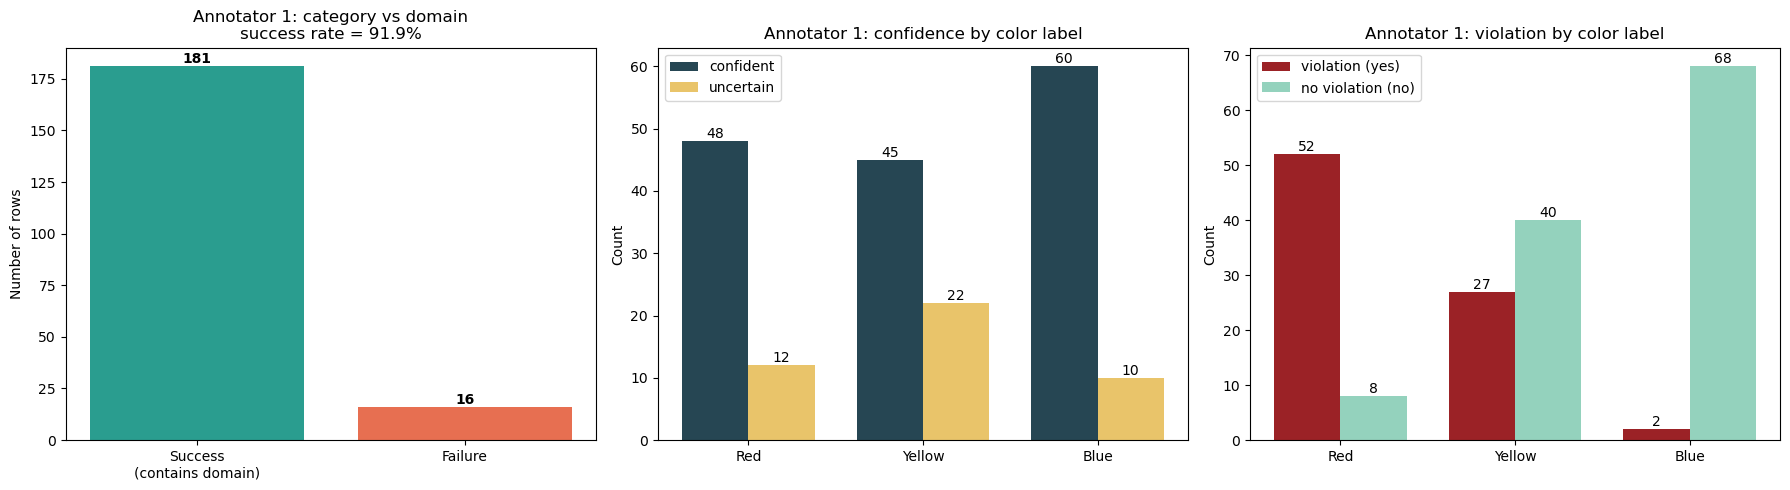

In [27]:
"""
Annotator-1-only analysis with visualizations.

1. Category vs domain: success = annotator_1 category CONTAINS the domain.
2. For each color_label (red / yellow / blue): how often annotator_1 is
   'confident' vs 'uncertain'.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 0. Clean (annotator_1 only)
# ---------------------------------------------------------------------------
df = df_sum.dropna().copy()
for c in ['annotator_1_category', 'annotator_1_confidence',
          'annotator_1_violation', 'color_label', 'domain']:
    df[c] = df[c].astype(str).str.strip().str.lower()

# ---------------------------------------------------------------------------
# 1. Category vs domain  -> success if domain string is contained in category
# ---------------------------------------------------------------------------
df['cat_success'] = df.apply(lambda r: r['domain'] in r['annotator_1_category'], axis=1)
success_counts = df['cat_success'].value_counts().reindex([True, False]).fillna(0).astype(int)
success_rate = df['cat_success'].mean()

print("=== Category vs domain (annotator_1) ===")
print(f"  success (contains domain): {success_counts[True]}")
print(f"  failure:                   {success_counts[False]}")
print(f"  success rate:              {success_rate:.1%}\n")

# ---------------------------------------------------------------------------
# 2. Confidence breakdown per color
# ---------------------------------------------------------------------------
order = [c for c in ['red', 'yellow', 'blue'] if c in df['color_label'].unique()]
conf_by_color = (df.groupby(['color_label', 'annotator_1_confidence'])
                   .size().unstack(fill_value=0)
                   .reindex(index=order)
                   .reindex(columns=['confident', 'uncertain'])
                   .fillna(0).astype(int))

print("=== Annotator_1 confidence count by color ===")
print(conf_by_color, "\n")

viol_by_color = (df.groupby(['color_label', 'annotator_1_violation'])
                   .size().unstack(fill_value=0)
                   .reindex(index=order)
                   .reindex(columns=['yes', 'no'])
                   .fillna(0).astype(int))

print("=== Annotator_1 violation count by color ===")
print(viol_by_color, "\n")

# ---------------------------------------------------------------------------
# 3. Visualize
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1 — category vs domain success
ax = axes[0]
bars = ax.bar(['Success\n(contains domain)', 'Failure'],
              [success_counts[True], success_counts[False]],
              color=['#2a9d8f', '#e76f51'])
ax.set_title(f"Annotator 1: category vs domain\nsuccess rate = {success_rate:.1%}")
ax.set_ylabel('Number of rows')
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            int(b.get_height()), ha='center', va='bottom', fontweight='bold')

# Panel 2 — confident vs uncertain by color
ax = axes[1]
x = np.arange(len(order))
w = 0.38
b1 = ax.bar(x - w / 2, conf_by_color['confident'], w, label='confident', color='#264653')
b2 = ax.bar(x + w / 2, conf_by_color['uncertain'], w, label='uncertain', color='#e9c46a')
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in order])
ax.set_title('Annotator 1: confidence by color label')
ax.set_ylabel('Count')
ax.legend()
for group in (b1, b2):
    for b in group:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                int(b.get_height()), ha='center', va='bottom')

# Panel 3 — violation vs non-violation by color
ax = axes[2]
b1 = ax.bar(x - w / 2, viol_by_color['yes'], w, label='violation (yes)', color='#9b2226')
b2 = ax.bar(x + w / 2, viol_by_color['no'], w, label='no violation (no)', color='#94d2bd')
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in order])
ax.set_title('Annotator 1: violation by color label')
ax.set_ylabel('Count')
ax.legend()
for group in (b1, b2):
    for b in group:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                int(b.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('annotator1_analysis.png', dpi=150, bbox_inches='tight')
plt.show()